In [234]:
print("all okay")

all okay


graph()
state
edges
nodes
invoke
stategraph()

In [235]:
def function1(input1):
    return input1+ " from first function"

In [236]:
def function2(input2):
    return input2+ " thomas from 2nd function"

In [237]:
def function3(input3):
    pass

In [238]:
function1("eby")

'eby from first function'

In [239]:
function2("thomas")

'thomas thomas from 2nd function'

In [240]:
from langgraph.graph import StateGraph


In [241]:
workflow1 =StateGraph(state_schema=str)

In [242]:
workflow1.add_node("fun1",function1)

In [243]:
workflow1.add_node("fun2",function2)

In [244]:
workflow1.add_edge("fun1","fun2")

In [245]:
workflow1.set_entry_point("fun1")

In [246]:
workflow1.set_finish_point("fun2")

In [247]:
app = workflow1.compile()

In [248]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'fun1': Node(id='fun1', name='fun1', data=fun1(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), 'fun2': Node(id='fun2', name='fun2', data=fun2(tags=None, recurse=True, explode_args=False, func_accepts_config=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='fun1', data=None, conditional=False), Edge(source='fun1', target='fun2', data=None, conditional=False), Edge(source='fun2', target='__end__', data=None, conditional=False)])

In [249]:
from IPython.display import Image, display

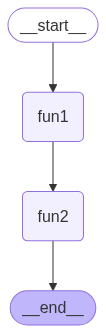

In [250]:
display(Image(app.get_graph().draw_mermaid_png()))

In [252]:
app.invoke("eby")

'eby from first function thomas from 2nd function'

In [253]:
for output in app.stream("eby"):
    for key, value in output.items():
        print(f"here is output from {key}")
        print("----")
        print(value)
        print("\n")

here is output from fun1
----
eby from first function


here is output from fun2
----
eby from first function thomas from 2nd function




In [266]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-1.5-flash')

In [268]:
model.invoke("hi").content

'Hi there! How can I help you today?'

In [269]:
def llm(input):
    from langchain_google_genai import ChatGoogleGenerativeAI
    model=ChatGoogleGenerativeAI(model='gemini-1.5-flash')
    output =model.invoke(input)
    return output.content

In [271]:
def token_counter(input):
    token=input.split()
    token_number =len(token)
    return token_number

In [273]:
workflow2 = StateGraph(state_schema=str)

In [274]:
workflow2.add_node("my_LLM",llm)

In [275]:
workflow2.add_node("LLM_Output_Token_Counter",token_counter)

In [276]:
workflow2.add_edge("my_LLM","LLM_Output_Token_Counter")

In [277]:
workflow2.set_entry_point("my_LLM")

In [278]:
workflow2.set_finish_point("LLM_Output_Token_Counter")

In [279]:
app = workflow2.compile()

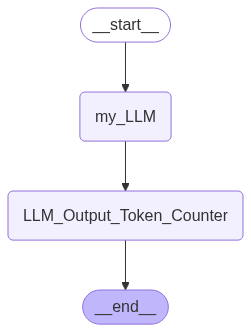

In [280]:
display(Image(app.get_graph().draw_mermaid_png()))

In [281]:
app.invoke("what is langgraph")

257

In [282]:

app.invoke("tell me about the tata enterpirse in very detail.")

717

In [283]:
for output in app.stream("tell me about the tata enterpirse in very detail."):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from my_LLM
_______
Tata Enterprises, more accurately referred to as the **Tata Group**, is a massive Indian multinational conglomerate headquartered in Mumbai.  It's not a single entity but a network of over 100 operating companies, spanning a breathtaking range of industries.  Understanding the Tata Group requires looking at its history, structure, philosophy, and key businesses.

**I. History:**

The Tata Group's origins trace back to 1868 with the establishment of a trading company by Jamsetji Tata.  His vision extended far beyond simple commerce; he aimed to build institutions that would contribute to India's progress.  Key milestones include:

* **Early Years (late 19th - early 20th century):**  Jamsetji Tata established foundational companies like Tata Iron and Steel Company (now Tata Steel), the Taj Mahal Palace Hotel, and the Tata Hydroelectric Power Supply Company. These were pioneering ventures in India at the time.
* **Diversification and Growth (mid-20th cen